In [1]:
import os
from scipy.signal import spectrogram 
from scipy.io import wavfile
import numpy as np
from PIL import Image
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

In [24]:
#Does not need to run each time 
#parameters for the split audio function 
input_file =r"C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\noise_target数据集\noise_target数据集\noise_未切分\DATA0001\DATA0033.wav"
output_dir='NoiseFragments2'
os.makedirs(output_dir, exist_ok=True)
chunk_duration=3
startingfilenumber=100


In [25]:
#Does not need to run eah time 
#Function Def for turning larger audio files into smaller 3 second fragments 
import os
import numpy as np
import librosa
import soundfile as sf

def split_audio_into_chunks(input_file, output_dir, chunk_duration=3,startingfilenumber=0):
    os.makedirs(output_dir, exist_ok=True)
    
    # Load audio file
    y, sr = librosa.load(input_file, sr=None)  # keep original sample rate
    
    chunk_samples = chunk_duration * sr
    total_samples = len(y)
    
    num_chunks = total_samples // chunk_samples
    
    for i in range(num_chunks):
        start = i * chunk_samples
        end = start + chunk_samples
        chunk = y[start:end]
        
        output_path = os.path.join(output_dir, f"chunk_{startingfilenumber:04d}.wav")
        sf.write(output_path, chunk, sr)
        startingfilenumber+=1
       
    
    print(f"Saved {num_chunks} chunks to {output_dir}")



In [26]:
#Does not need to run each time 
#Usage for the split_audio function 
split_audio_into_chunks(input_file, output_dir, chunk_duration,startingfilenumber)

Saved 100 chunks to NoiseFragments2


In [ ]:
#Block of code for augmenting the 3 second noise chunks to create more training data for the model.
#There are 5 varitatioons of augmentations but we ramdomize the chance of each happening and limit to 3 to create more variety in the augmented data.
import audiomentations as A
import librosa
import soundfile as sf
import os

# Define augmentation pipeline
augment = A.Compose([
    A.AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),  # Subtle background noise
    A.TimeStretch(min_rate=0.9, max_rate=1.1, p=0.5),  # Slight speed changes
    A.PitchShift(min_semitones=-1, max_semitones=1, p=0.5),  # Minor pitch shifts
    A.Shift(min_shift=-0.2, max_shift=0.2, p=0.5),  # Time shifts (in seconds)
    A.Gain(min_gain_db=-3, max_gain_db=3, p=0.5)  # Volume adjustments
])

# Paths
noise_folder = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\NoiseFragments2"  # Folder with your 3-sec noise WAVs
augmented_output = "NoiseFragments2_Augmented"  # New folder for augmented files
os.makedirs(augmented_output, exist_ok=True)


# Augment each file 
for file in os.listdir(noise_folder):
    if file.endswith('.wav'):
        file_path = os.path.join(noise_folder, file)
        y, sr = librosa.load(file_path, sr=None)
        
        # Generate 3 augmented versions per original
        for i in range(3):
            y_aug = augment(y, sample_rate=sr)
            aug_file = os.path.join(augmented_output, f"{os.path.splitext(file)[0]}_aug{i}.wav")
            sf.write(aug_file, y_aug, sr)

print("Augmentation complete!")

Augmentation complete!


In [31]:
#Does not need to run each time
#function for combining folder files into one
import os
import shutil

def combine_folders(source_folders, destination_folder, move_files=False):
    """
    Combines contents of multiple folders into a single folder.
    
    Parameters:
        source_folders (list): List of folder paths to combine
        destination_folder (str): Target folder path
        move_files (bool): If True, moves files. If False, copies files.
    """
    
    os.makedirs(destination_folder, exist_ok=True)
    
    for folder in source_folders:
        for root, _, files in os.walk(folder):
            for file in files:
                source_path = os.path.join(root, file)
                
                # Handle duplicate filenames
                base_name = file
                name, ext = os.path.splitext(base_name)
                counter = 1
                dest_path = os.path.join(destination_folder, base_name)
                
                while os.path.exists(dest_path):
                    new_name = f"{name}_{counter}{ext}"
                    dest_path = os.path.join(destination_folder, new_name)
                    counter += 1
                
                if move_files:
                    shutil.move(source_path, dest_path)
                else:
                    shutil.copy2(source_path, dest_path)

    print("Done combining folders.")


In [33]:
#Does not need to run each time 
#using combin_folders function
source_dirs = [
    r"C:\Users\yusle\OneDrive\Desktop\boat_audio\NoiseFragments1",
    r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\NoiseFragments1_Augmented",
    r"C:\Users\yusle\OneDrive\Desktop\boat_audio\NoiseFragments2",
    r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\NoiseFragments2_Augmented"
]

combine_folders(source_dirs, "combined_noise", move_files=False)


Done combining folders.


In [34]:
audio_folder=r'C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise'
output_folder='2_spec'
os.makedirs(output_folder, exist_ok=True)

In [35]:
# We need to create parmeters for the spectrogram
freq_min=10
freq_max=10000
window_size=1024
overlapp=800
n_fft=1024*4  #2^10

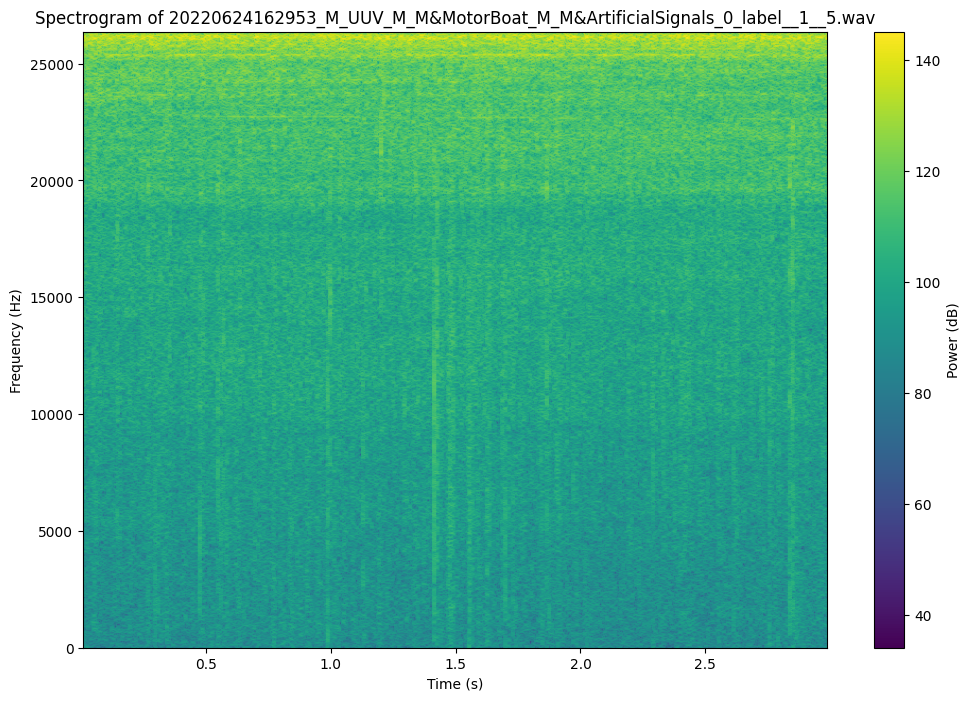

The frequency with the highest average power (most noticeable) is 218.87 Hz


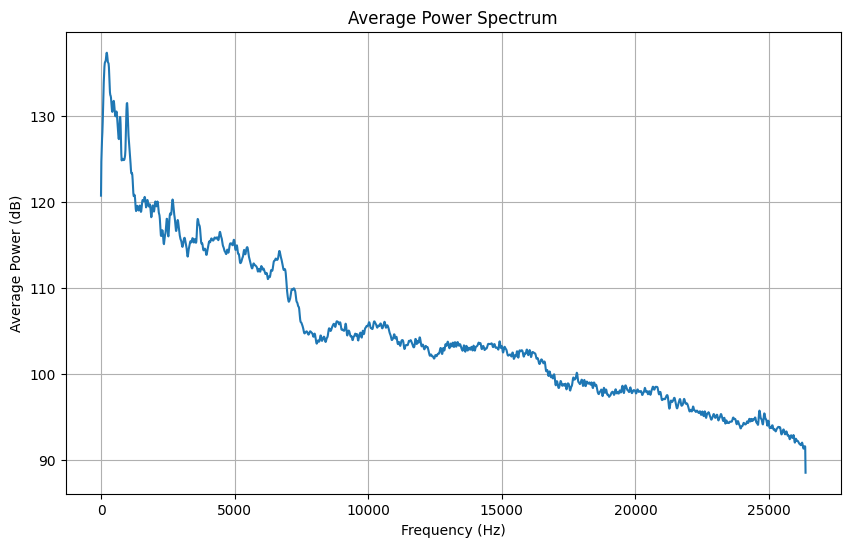

In [14]:
# Code for testing a single audio file: generate spectrogram, display it, and find the frequency with highest average power

import matplotlib.pyplot as plt

# Set the path to your single audio file
file_path = r"C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\UUV\UUV数据集\target\20220624162953_M_UUV_M_M&MotorBoat_M_M&ArtificialSignals_0_label__1__5.wav"  # Example path, change as needed

# Read the audio file
fs, x = wavfile.read(file_path)

# Compute the spectrogram
f, t, S = spectrogram(x, fs, nperseg=window_size, noverlap=overlapp, nfft=n_fft)

# Use full frequency range (no mask)
sxx = S

# Convert to dB
G = 10 * np.log10(sxx + 1e-8)

# Flip for display (high freq at top)
G_flipped = np.flipud(G)

# Display the spectrogram
plt.figure(figsize=(12, 8))
plt.imshow(G_flipped, aspect='auto', origin='lower', extent=[t.min(), t.max(), f.min(), f.max()])
plt.colorbar(label='Power (dB)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Spectrogram of ' + os.path.basename(file_path))
plt.show()

# Analyze the average power per frequency to find the most prominent frequency
avg_power = np.mean(sxx, axis=1)  # Average over time for each frequency bin
max_idx = np.argmax(avg_power)
prominent_freq = f[max_idx]

print(f"The frequency with the highest average power (most noticeable) is {prominent_freq:.2f} Hz")

# Optionally, plot the average power spectrum
plt.figure(figsize=(10, 6))
plt.plot(f, 10 * np.log10(avg_power + 1e-8))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Average Power (dB)')
plt.title('Average Power Spectrum')
plt.grid(True)
plt.show()

In [ ]:
#loop for turning audio files in the directed folder into spectrogram with a mask and then normilzing it and saving the image to the output folder
for file in os.listdir(audio_folder):
    file_path= os.path.join(audio_folder,file)
    print(file_path)
    fs,x=wavfile.read(file_path)
    f,t,S=spectrogram(x,fs,nperseg=window_size,noverlap=overlapp,nfft=n_fft)
    f_mask=(f>=freq_min)&(f<=freq_max)
    sxx=S[f_mask,:]
    G=10*np.log10(sxx+1e-8)
    G=np.flipud(G)
    # normalize the spectrogram
    norm=Normalize(vmin=np.min(G),vmax=np.max(G))
    G_normalized=norm(G)
    # convert spectrogram to image
    G_colormap=plt.cm.jet( G_normalized)
    G_image=( G_colormap[:,:,:3]*255).astype(np.uint8)
    G_resized=Image.fromarray(G_image).resize((224,224))
    output_file=os.path.join(output_folder,os.path.basename(file_path).replace('.wav','.png'))
    G_resized.save(  output_file)
    
        
    

C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0000.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0001.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0002.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0003.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0004.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0005.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0006.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0007.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0008.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0009.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositori

In [36]:
#loop for turning audio files in the directed folder into spectrogram (without) a mask and then normilzing it and saving the image to the output folder
for file in os.listdir(audio_folder):
    file_path= os.path.join(audio_folder,file)
    print(file_path)
    fs,x=wavfile.read(file_path)
    f,t,S=spectrogram(x,fs,nperseg=window_size,noverlap=overlapp,nfft=n_fft)
    sxx=S
    G=10*np.log10(sxx+1e-8)
    G=np.flipud(G)
    # normalize the spectrogram
    norm=Normalize(vmin=np.min(G),vmax=np.max(G))
    G_normalized=norm(G)
    # convert spectrogram to image
    G_colormap=plt.cm.jet( G_normalized)
    G_image=( G_colormap[:,:,:3]*255).astype(np.uint8)
    G_resized=Image.fromarray(G_image).resize((224,224))
    output_file=os.path.join(output_folder,os.path.basename(file_path).replace('.wav','.png'))
    G_resized.save(  output_file)
    
        
    

C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0000.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0000_aug0.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0000_aug1.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0000_aug2.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0001.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0001_aug0.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0001_aug1.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0001_aug2.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0002.wav
C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\combined_noise\chunk_0002_aug0.wav
C:\Users\yusle\

In [19]:
# create model for training
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

In [20]:
#for splitting folder with subfolder classes into folder with train and validation 70/30 split folder and each having all the subfolder classes  
import os
import shutil
import random

# ===== CONFIG =====
source_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\classesFullSpec"   # folder with class subfolders
train_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\classesFullSpec_split\Train"
test_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\classesFullSpec_split\Val"
split_ratio = 0.7
random_seed = 42
# ==================

random.seed(random_seed)

# Create Train and Test directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Loop over each class folder
for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    # Create class folders in Train and Test
    train_class_dir = os.path.join(train_dir, class_name)
    test_class_dir = os.path.join(test_dir, class_name)

    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(test_class_dir, exist_ok=True)

    # Get all image files
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    random.shuffle(images)

    split_index = int(len(images) * split_ratio)
    train_images = images[:split_index]
    test_images = images[split_index:]

    # Copy files
    for img in train_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(train_class_dir, img)
        )

    for img in test_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(test_class_dir, img)
        )

    print(f"{class_name}: {len(train_images)} train / {len(test_images)} test")

print("✅ Dataset split complete.")


1_spec: 1866 train / 801 test
2_spec: 560 train / 240 test
3_spec: 2617 train / 1122 test
4_spec: 631 train / 271 test
✅ Dataset split complete.


In [22]:
# prepare data
data_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\classesFullSpec_split"  # Replace with your folder path
# Hyperparameters
batch_size = 32
num_epochs = 60
learning_rate = 0.001
num_classes =4  # Number of subfolders-(each folder is a class)
print(num_classes)

# Image transformations
transform = transforms.Compose([transforms.ToTensor()])

4


In [23]:
# Load dataset
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "Train"), transform=transform)
val_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "Val"), transform=transform)

In [24]:

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [25]:
class ViTModel(nn.Module):
    def __init__(self, num_classes):
        super(ViTModel, self).__init__()
        # Load pretrained Vision Transformer model
        self.model = models.vit_b_16(pretrained=True)
        
        # Replace the head (classification layer)
        in_features = self.model.heads.head.in_features  # Get input features of the head
        self.model.heads.head = nn.Linear(in_features, num_classes)  # Replace with new classification layer

    def forward(self, x):
        return self.model(x)

In [26]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
NVIDIA GeForce RTX 3070


In [27]:
class ResNet18Model(nn.Module):
    def __init__(self, num_classes):
        super(ResNet18Model, self).__init__()
        
        self.model = models.resnet18(pretrained=True)
        
        # Replace final fully connected layer
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [10]:
class ResNet50Model(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Model, self).__init__()
        
        self.model = models.resnet50(pretrained=True)
        
        # Replace final fully connected layer
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [10]:
#declaring the efficentNetModel structure 
class EfficientNetModel(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetModel, self).__init__()
        self.model = models.efficientnet_b0(pretrained=True)
        self.model.classifier[1] = nn.Linear(self.model.classifier[1].in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [28]:
class EfficientNetModel_Mine(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(pretrained=True)

        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)


In [29]:
#declaring the efficentNetModel b0 structure 
class EfficientNetModel(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetModel, self).__init__()
        self.model = models.efficientnet_b0(pretrained=True)
        self.model.classifier[1] = nn.Linear(self.model.classifier[1].in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [30]:
# Initialize models, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

#loading the models to the device and declaring them
vit_model = ViTModel(num_classes).to(device)
efficientnet_model = EfficientNetModel(num_classes).to(device)
resnet_model = ResNet50Model(num_classes).to(device)

#loss function and optimizers for each model
criterion = nn.CrossEntropyLoss()
vit_optimizer = optim.Adam(vit_model.parameters(), lr=learning_rate)
efficientnet_optimizer = optim.Adam(efficientnet_model.parameters(), lr=learning_rate)
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=learning_rate)


cuda


In [ ]:
def train_model(model, optimizer, train_loader, val_loader, num_epochs, model_name):
    maxAccuracy=80
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Training {model_name} Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        train_loss /= len(train_loader.dataset)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        accuracy = correct / total * 100

        print(f"{model_name} Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {accuracy:.2f}%")
        #saving best model 
        if accuracy > maxAccuracy: 
            torch.save(efficientnet_model.state_dict(), 'efficientnet_model.pth')
            maxAccuracy=accuracy
            print(f"Saved model with best accuracy of {maxAccuracy:.2f}%")
        


In [33]:
def train_model(model, optimizer, train_loader, val_loader, num_epochs, model_name, num_classes):
    max_mean_accuracy = 87.0

    for epoch in range(num_epochs):

        # ------------------ TRAIN ------------------
        model.train()
        train_loss = 0.0

        for inputs, labels in tqdm(train_loader, desc=f"Training {model_name} Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        train_loss /= len(train_loader.dataset)

        # ------------------ VALIDATION ------------------
        model.eval()
        val_loss = 0.0

        correct = 0
        total = 0

        # Per-class tracking
        class_correct = torch.zeros(num_classes)
        class_total = torch.zeros(num_classes)

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                # Per-class stats
                for i in range(len(labels)):
                    label = labels[i]
                    class_total[label] += 1
                    if predicted[i] == label:
                        class_correct[label] += 1

        val_loss /= len(val_loader.dataset)
        overall_accuracy = 100 * correct / total

        # Compute per-class accuracy
        class_accuracies = 100 * class_correct / class_total.clamp(min=1)

        # Mean class accuracy (balanced accuracy)
        mean_class_accuracy = class_accuracies.mean().item()

        # ------------------ PRINT METRICS ------------------
        print(f"\n{model_name} Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Overall Accuracy: {overall_accuracy:.2f}%")
        print(f"Mean Class Accuracy: {mean_class_accuracy:.2f}%")

        for i in range(num_classes):
            print(f"Class {i} Accuracy: {class_accuracies[i]:.2f}%")

        # ------------------ SAVE BEST MODEL ------------------
        if mean_class_accuracy > max_mean_accuracy:
            torch.save(model.state_dict(), f"{model_name}_best_boat_{mean_class_accuracy:.2f}%.pth")
            max_mean_accuracy = mean_class_accuracy
            print(f"Saved best model with Mean Class Accuracy: {max_mean_accuracy:.2f}%\n")
            
        if class_accuracies[0] > 70 and class_accuracies[1] > 70 and class_accuracies[2] > 70 and class_accuracies[3] > 70:
            torch.save(model.state_dict(), f"{model_name}_best_boat_cm{mean_class_accuracy:.2f}%_c1{class_accuracies[0]:.2f}%_c2{class_accuracies[1]:.2f}%_c3{class_accuracies[2]:.2f}%_c4{class_accuracies[3]:.2f}%.pth")
            if mean_class_accuracy > max_mean_accuracy:
                max_mean_accuracy = mean_class_accuracy
            print(f"Saved best model with Mean Class Accuracy: {max_mean_accuracy:.2f}%\n")
        


In [44]:

# Train Vision Transformer
train_model(vit_model, vit_optimizer, train_loader, val_loader, num_epochs, "ViT", num_classes)

Training ViT Epoch 1/50:   1%|          | 2/178 [00:01<02:55,  1.00it/s]


KeyboardInterrupt: 

In [15]:
#train resnet50
train_model(resnet_model, resnet_optimizer, train_loader, val_loader, num_epochs, "ResNet50", num_classes)

Training ResNet50 Epoch 1/40: 100%|██████████| 355/355 [00:35<00:00,  9.89it/s]



ResNet50 Epoch 1/40
Train Loss: 0.8719
Val Loss: 0.8471
Overall Accuracy: 60.07%
Mean Class Accuracy: 58.31%
Class 0 Accuracy: 28.34%
Class 1 Accuracy: 63.33%
Class 2 Accuracy: 82.17%
Class 3 Accuracy: 59.41%


Training ResNet50 Epoch 2/40: 100%|██████████| 355/355 [00:35<00:00,  9.89it/s]



ResNet50 Epoch 2/40
Train Loss: 0.7586
Val Loss: 0.7604
Overall Accuracy: 65.98%
Mean Class Accuracy: 69.46%
Class 0 Accuracy: 29.84%
Class 1 Accuracy: 97.50%
Class 2 Accuracy: 85.20%
Class 3 Accuracy: 65.31%


Training ResNet50 Epoch 3/40: 100%|██████████| 355/355 [00:35<00:00,  9.87it/s]


...


ResNet50 Epoch 38/40
Train Loss: 0.2943
Val Loss: 0.4341
Overall Accuracy: 73.95%
Mean Class Accuracy: 78.61%
Class 0 Accuracy: 82.65%
Class 1 Accuracy: 100.00%
Class 2 Accuracy: 63.55%
Class 3 Accuracy: 68.27%


Training ResNet50 Epoch 39/40: 100%|██████████| 355/355 [00:35<00:00,  9.97it/s]



ResNet50 Epoch 39/40
Train Loss: 0.2974
Val Loss: 0.4585
Overall Accuracy: 74.40%
Mean Class Accuracy: 76.56%
Class 0 Accuracy: 45.82%
Class 1 Accuracy: 99.58%
Class 2 Accuracy: 90.37%
Class 3 Accuracy: 70.48%


Training ResNet50 Epoch 40/40: 100%|██████████| 355/355 [00:35<00:00,  9.94it/s]



ResNet50 Epoch 40/40
Train Loss: 0.2963
Val Loss: 0.7072
Overall Accuracy: 71.53%
Mean Class Accuracy: 70.45%
Class 0 Accuracy: 46.94%
Class 1 Accuracy: 57.50%
Class 2 Accuracy: 87.70%
Class 3 Accuracy: 89.67%


In [32]:
import numpy as np
print("NumPy version:", np.__version__)
print("NumPy path:", np.__file__)

NumPy version: 1.26.4
NumPy path: c:\Users\yusle\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\__init__.py


In [34]:
# Train EfficientNet
train_model(efficientnet_model, efficientnet_optimizer, train_loader, val_loader, num_epochs, "EfficientNet", num_classes)


Training EfficientNet Epoch 1/60: 100%|██████████| 178/178 [00:25<00:00,  6.85it/s]



EfficientNet Epoch 1/60
Train Loss: 0.7145
Val Loss: 0.7304
Overall Accuracy: 65.04%
Mean Class Accuracy: 74.42%
Class 0 Accuracy: 41.07%
Class 1 Accuracy: 99.17%
Class 2 Accuracy: 69.25%
Class 3 Accuracy: 88.19%


Training EfficientNet Epoch 2/60: 100%|██████████| 178/178 [00:24<00:00,  7.29it/s]



EfficientNet Epoch 2/60
Train Loss: 0.5526
Val Loss: 0.4978
Overall Accuracy: 74.32%
Mean Class Accuracy: 74.38%
Class 0 Accuracy: 47.19%
Class 1 Accuracy: 99.58%
Class 2 Accuracy: 92.07%
Class 3 Accuracy: 58.67%


Training EfficientNet Epoch 3/60: 100%|██████████| 178/178 [00:24<00:00,  7.28it/s]


...


EfficientNet Epoch 58/60
Train Loss: 0.2493
Val Loss: 0.7157
Overall Accuracy: 68.98%
Mean Class Accuracy: 77.67%
Class 0 Accuracy: 68.16%
Class 1 Accuracy: 99.58%
Class 2 Accuracy: 59.54%
Class 3 Accuracy: 83.39%


Training EfficientNet Epoch 59/60: 100%|██████████| 178/178 [00:24<00:00,  7.26it/s]



EfficientNet Epoch 59/60
Train Loss: 0.2534
Val Loss: 0.9085
Overall Accuracy: 67.63%
Mean Class Accuracy: 73.07%
Class 0 Accuracy: 62.17%
Class 1 Accuracy: 99.17%
Class 2 Accuracy: 65.24%
Class 3 Accuracy: 65.68%


Training EfficientNet Epoch 60/60: 100%|██████████| 178/178 [00:24<00:00,  7.28it/s]



EfficientNet Epoch 60/60
Train Loss: 0.2535
Val Loss: 0.7863
Overall Accuracy: 68.49%
Mean Class Accuracy: 77.39%
Class 0 Accuracy: 56.30%
Class 1 Accuracy: 99.58%
Class 2 Accuracy: 65.86%
Class 3 Accuracy: 87.82%


In [ ]:
# SAVE (after training)
torch.save(efficientnet_model.state_dict(), f'efficientnet_best.pth')



In [ ]:
# Initialize models, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

vit_model = ViTModel(num_classes).to(device)
MyModel = EfficientNetModel(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
vit_optimizer = optim.Adam(vit_model.parameters(), lr=learning_rate)
efficientnet_optimizer = optim.Adam(efficientnet_model.parameters(), lr=learning_rate)

In [50]:
# LOAD (in your Flask app)
model = MyModel()
model.load_state_dict(torch.load('model.pth', map_location='cpu'))
model.eval()

NameError: name 'MyModel' is not defined

In [ ]:
# Example single datapoint
sample = torch.randn(40)

# Add batch dimension (VERY IMPORTANT)
sample = sample.unsqueeze(0)

with torch.no_grad():
    output = model(sample)

predicted_class = torch.argmax(output, dim=1)
print("Prediction:", predicted_class.item())


fix code from here down 

In [7]:
from torchvision import datasets
from torch.utils.data import DataLoader

val_dataset = datasets.ImageFolder(
    root=r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\SplitClasses\Val",
    transform=transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

class_names = val_dataset.classes
num_classes = len(class_names)


NameError: name 'transform' is not defined

In [8]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score


In [9]:
def evaluate_model(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Accuracy
    accuracy = accuracy_score(all_labels, all_preds)

    # Recall (macro)
    recall = recall_score(all_labels, all_preds, average="macro")

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Sensitivity & Specificity
    sensitivity = []
    specificity = []

    for i in range(len(cm)):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FN + FP)

        sens = TP / (TP + FN) if (TP + FN) > 0 else 0
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0

        sensitivity.append(sens)
        specificity.append(spec)

    results = {
        "accuracy": accuracy,
        "recall_macro": recall,
        "sensitivity_per_class": sensitivity,
        "specificity_per_class": specificity,
        "sensitivity_macro": np.mean(sensitivity),
        "specificity_macro": np.mean(specificity),
        "confusion_matrix": cm
    }

    return results


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

metrics = evaluate_model(model, val_loader, device)


NameError: name 'model' is not defined

In [ ]:
print(f"Accuracy:    {metrics['accuracy']:.4f}")
print(f"Recall:      {metrics['recall_macro']:.4f}")
print(f"Sensitivity: {metrics['sensitivity_macro']:.4f}")
print(f"Specificity: {metrics['specificity_macro']:.4f}")

print("\nPer-class metrics:")
for i, class_name in enumerate(class_names):
    print(
        f"{class_name:10s} | "
        f"Sensitivity: {metrics['sensitivity_per_class'][i]:.4f} | "
        f"Specificity: {metrics['specificity_per_class'][i]:.4f}"
    )
